# 繪製4張地圖

## 繪製 Basemap

In [2]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

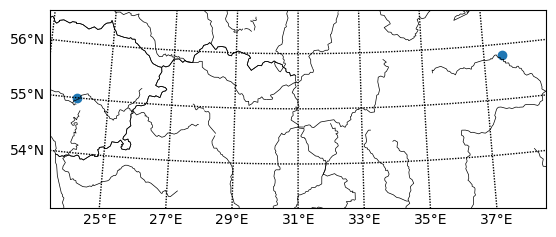

In [3]:
m = Basemap(projection='lcc', resolution='i', width=1000000, height=400000, lon_0=31, lat_0=55)
lons=[24.0, 37.6]
lats=[55.0, 55.8]
m.drawcountries()
m.drawrivers()
m.drawparallels(range(54,58), labels=[True, False, False, False])
m.drawmeridians(range(23, 38, 2), labels=[False, False, False, True])
xi, yi = m(lons, lats)
m.scatter(xi, yi)
plt.show()

## 繪製城市圖

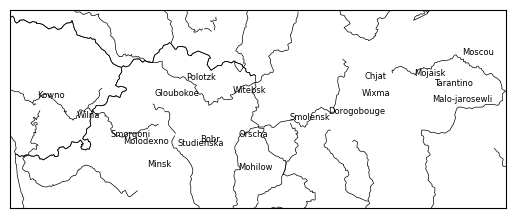

In [4]:
connection = sqlite3.connect('data/minard.db')
city_df = pd.read_sql("""SELECT * FROM cities;""", connection)
connection.close()

lons = city_df['lonc'].values
lats = city_df['latc'].values
city_names = city_df['city'].values
fig, ax = plt.subplots()
m = Basemap(projection='lcc', resolution='i', width=1000000, height=400000, lon_0=31, lat_0=55, ax=ax)
m.drawcountries()
m.drawrivers()
x, y = m(lons, lats)
for xi, yi, city_name in zip(x, y, city_names):
    ax.annotate(text=city_name, xy=(xi, yi), fontsize=6)
plt.show()

## 繪製氣溫圖

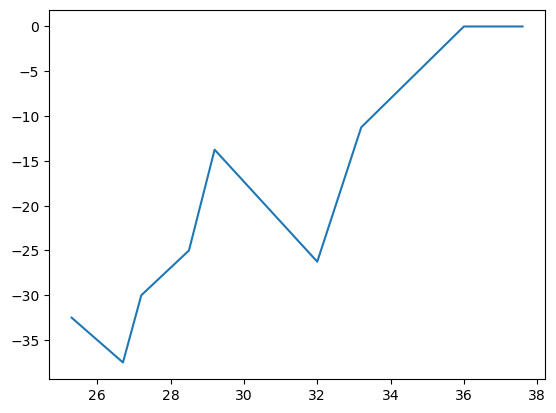

In [5]:
connection = sqlite3.connect('data/minard.db')
temperature_df = pd.read_sql("""SELECT * FROM temperatures;""", con=connection)
connection.close()

temp_celsius = (temperature_df['temp'] * 5/4).values
lons = temperature_df['lont'].values
fig, ax = plt.subplots()
ax.plot(lons, temp_celsius)
plt.show()

## 繪製軍隊圖

In [6]:
connection = sqlite3.connect('data/minard.db')
troop_df = pd.read_sql("""SELECT * FROM troops;""", con=connection)
connection.close()

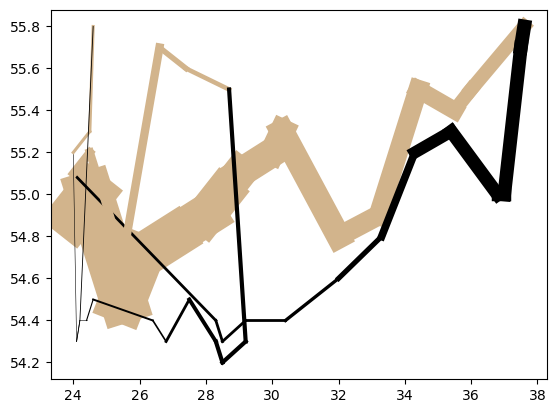

In [7]:
fig, ax = plt.subplots()
rows = troop_df.shape[0]
lons = troop_df['lonp'].values
lats = troop_df['latp'].values
survivals = troop_df['surviv'].values
directions = troop_df['direc'].values
for i in range(rows-1):
    if directions[i] == 'A':
        line_color = 'tan'
    else:
        line_color = 'black'
    start_stop_lons = (lons[i], lons[i+1])
    start_stop_lats = (lats[i], lats[i+1])
    line_width = survivals[i]
    ax.plot(start_stop_lons, start_stop_lats, linewidth=line_width/10000, color=line_color)
plt.show()

# 4張圖合併：繪製底圖

In [8]:
connection = sqlite3.connect('data/minard.db')
city_df = pd.read_sql("""SELECT * FROM cities;""", con=connection)
temperature_df = pd.read_sql("""SELECT * FROM temperatures;""", con=connection)
troop_df = pd.read_sql("""SELECT * FROM troops;""", con=connection)
connection.close()

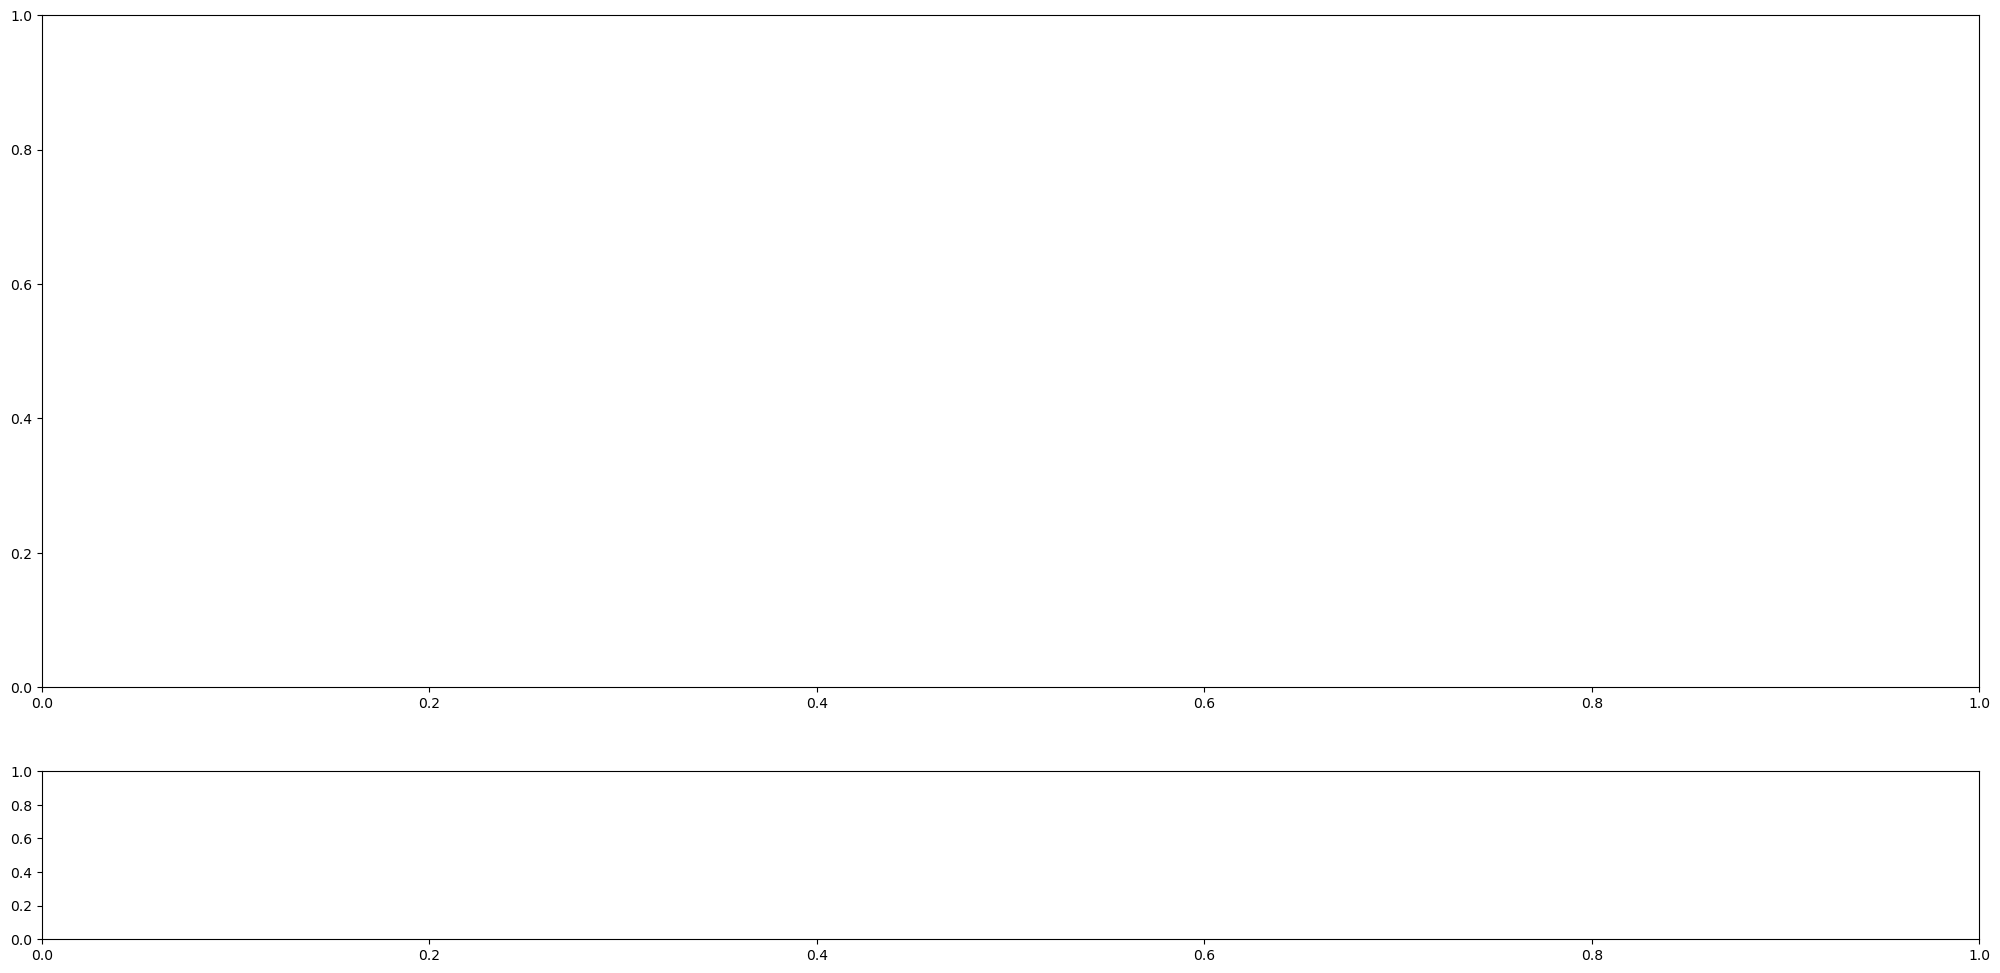

In [9]:
fig, axes = plt.subplots(nrows=2, figsize = (25, 12), gridspec_kw={'height_ratios': [4, 1]})
plt.show()

# 4張圖合併：繪製地圖(底圖)、城市圖、軍隊圖與氣溫圖

In [10]:
connection = sqlite3.connect('data/minard.db')
city_df = pd.read_sql("""SELECT * FROM cities;""", con=connection)
temperature_df = pd.read_sql("""SELECT * FROM temperatures;""", con=connection)
troop_df = pd.read_sql("""SELECT * FROM troops;""", con=connection)
connection.close()

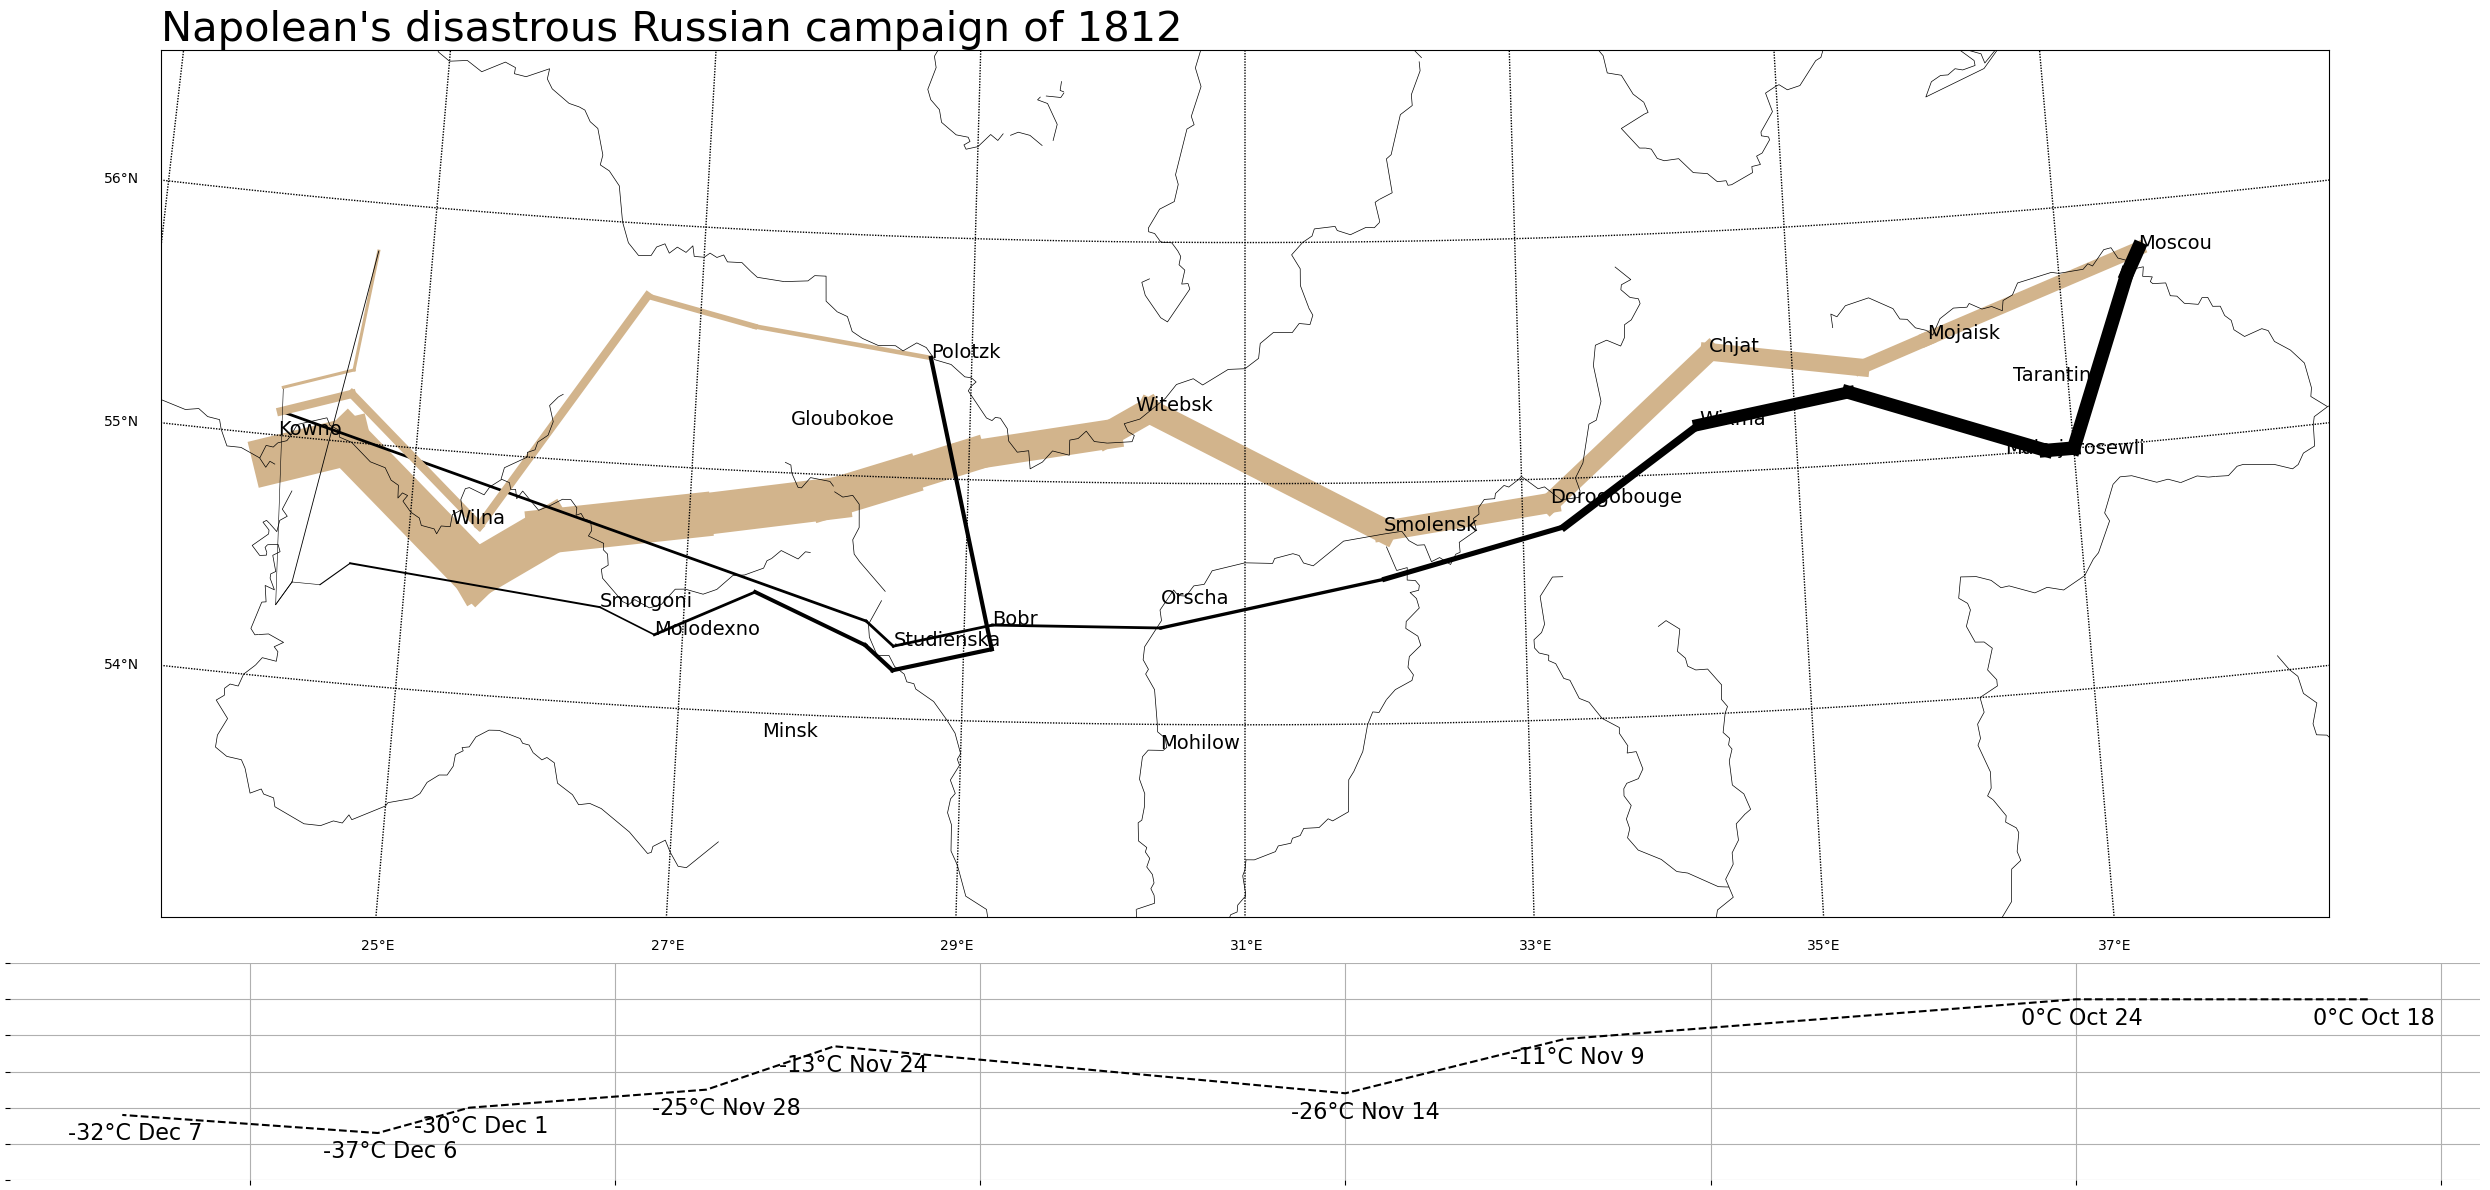

In [15]:
loncs = city_df['lonc'].values
latcs = city_df['latc'].values
city_names = city_df['city'].values
rows = troop_df.shape[0]
lonps = troop_df['lonp'].values
latps = troop_df['latp'].values
survivals = troop_df['surviv'].values
directions = troop_df['direc'].values
divisions = troop_df['division'].values
temp_celsius = (temperature_df['temp'] * 5/4).astype(int)
lonts = temperature_df['lont'].values
annotations = temp_celsius.astype(str).str.cat(temperature_df['date'], sep='°C ')
fig, axes = plt.subplots(nrows=2, figsize=(25, 12), gridspec_kw={'height_ratios':[4, 1]}) # 繪製底圖、上下2個軸物件
m = Basemap(projection='lcc', resolution='i', width=1000000, height=400000, lon_0=31, lat_0=55, ax=axes[0])
m.drawcounties()
m.drawrivers()
m.drawparallels(range(54, 58), labels=[True, False, False, False])
m.drawmeridians(range(23, 38, 2), labels=[False, False, False, True])

"""繪製城市名稱資料"""
x, y = m(loncs, latcs)
for xi, yi, city_name in zip(x, y, city_names):
    axes[0].annotate(text=city_name, xy=(xi, yi), fontsize=14, zorder=2)

"""繪製軍隊資料"""
x, y = m(lonps, latps)
for i in range(rows-1):
    if directions[i] == 'A':
        line_color = 'tan'
    else:
        line_color = 'black'
    start_stop_lonps = (x[i], x[i+1])
    start_stop_latps = (y[i], y[i+1])
    line_width = survivals[i]
    m.plot(start_stop_lonps, start_stop_latps, linewidth = line_width/10000, color=line_color, zorder= 1)

"""繪製氣溫資料"""
axes[1].plot(lonts, temp_celsius, linestyle='dashed', color='black')
for lont, temp_c, annotation in zip(lonts, temp_celsius, annotations):
    axes[1].annotate(annotation, xy=(lont-0.3, temp_c-7), fontsize=16)
axes[1].set_ylim(-50, 10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].grid(True, which='major', axis='both')
axes[1].set_xticklabels([])
axes[1].set_yticklabels([])
axes[0].set_title("Napolean's disastrous Russian campaign of 1812", loc='left', fontsize=30)
plt.tight_layout()
fig.savefig('minard_clone.png')